In [1]:
# ================================================
# Task 1 — Load and inspect data
# Check for anomalies in amounts
# ================================================

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Load dataset
df = pd.read_csv('personal_finance.csv')

# Basic info
print("SHAPE:", df.shape)
print("\nDATATYPES:\n", df.dtypes)
print("\nMISSING VALUES:\n", df.isnull().sum())
print("\nDUPLICATES:", df.duplicated().sum())

# Check for anomalies in amounts
print("\nAMOUNT STATISTICS:")
print(df['amount_ngn'].describe())
print("\nNegative amounts:", (df['amount_ngn'] < 0).sum())
print("Zero amounts:", (df['amount_ngn'] == 0).sum())

df.head()

SHAPE: (75000, 14)

DATATYPES:
 transaction_id          str
user_id                 str
transaction_date        str
month                   str
year                  int64
transaction_type        str
category                str
amount_ngn          float64
description             str
payment_method          str
bank                    str
savings_goal_met        str
budget_category         str
notes                   str
dtype: object

MISSING VALUES:
 transaction_id          0
user_id                 0
transaction_date        0
month                   0
year                    0
transaction_type        0
category                0
amount_ngn              0
description             0
payment_method          0
bank                    0
savings_goal_met    24994
budget_category         0
notes               21618
dtype: int64

DUPLICATES: 0

AMOUNT STATISTICS:
count    7.500000e+04
mean     1.076141e+05
std      1.803244e+05
min      2.000000e+02
25%      1.755000e+04
50%      4.205000e+04


,transaction_id,user_id,transaction_date,month,year,transaction_type,category,amount_ngn,description,payment_method,bank,savings_goal_met,budget_category,notes
0,TXN-500000,USR-500752,2022-11-29,November,2022,Expense,Investment,68080.0,Reflect despite loss.,Card,Palmpay,No,Investment,Planned
1,TXN-500001,USR-502966,2021-02-14,February,2021,Expense,Investment,15290.0,Model sea everybody American same.,USSD,Opay,Yes,Investment,NaN
2,TXN-500002,USR-502387,2021-08-16,August,2021,Expense,Transport,22650.0,Thank assume claim.,Cash,Access,No,Transport,Unexpected
3,TXN-500003,USR-502251,2022-07-05,July,2022,Expense,Entertainment,32220.0,Possible color account spend.,POS,Kuda,No,Entertainment,Monthly
4,TXN-500004,USR-502756,2023-08-24,August,2023,Expense,Investment,15710.0,Same democratic.,Card,Access,NaN,Investment,Planned


In [2]:
# ================================================
# Task 2 — Data preparation:
# - Convert dates
# - Fill missing values
# - Separate income and expense
# - Compute net savings per user per month
# ================================================

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Fill missing values
df['savings_goal_met'] = df['savings_goal_met'].fillna('N/A')
df['notes']            = df['notes'].fillna('Unknown')

# Confirm no more missing values
print("Missing values after fix:\n", df.isnull().sum())

# Separate income and expense
income_df  = df[df['transaction_type'] == 'Income'].copy()
expense_df = df[df['transaction_type'] == 'Expense'].copy()

print(f"\nTotal Income transactions:  {len(income_df):,}")
print(f"Total Expense transactions: {len(expense_df):,}")

# Compute net savings per user per month
monthly_income = (income_df.groupby(['user_id', 'year', 'month'])
                  ['amount_ngn'].sum()
                  .reset_index()
                  .rename(columns={'amount_ngn': 'total_income'}))

monthly_expense = (expense_df.groupby(['user_id', 'year', 'month'])
                   ['amount_ngn'].sum()
                   .reset_index()
                   .rename(columns={'amount_ngn': 'total_expense'}))

# Merge income and expense
monthly_savings = pd.merge(monthly_income, monthly_expense,
                           on=['user_id', 'year', 'month'],
                           how='outer').fillna(0)

# Calculate net savings
monthly_savings['net_savings'] = (monthly_savings['total_income'] - 
                                  monthly_savings['total_expense'])

print("\nNet Savings Summary:")
print(f"Total Users:          {monthly_savings['user_id'].nunique():,}")
print(f"Avg Monthly Savings:  ₦{monthly_savings['net_savings'].mean():,.0f}")
print(f"Users with negative savings: {(monthly_savings['net_savings'] < 0).sum():,}")

monthly_savings.head()

Missing values after fix:
 transaction_id      0
user_id             0
transaction_date    0
month               0
year                0
transaction_type    0
category            0
amount_ngn          0
description         0
payment_method      0
bank                0
savings_goal_met    0
budget_category     0
notes               0
dtype: int64

Total Income transactions:  11,449
Total Expense transactions: 63,551

Net Savings Summary:
Total Users:          5,000
Avg Monthly Savings:  ₦12,067
Users with negative savings: 50,401


,user_id,year,month,total_income,total_expense,net_savings
0,USR-500000,2021,August,0.0,35460.0,-35460.0
1,USR-500000,2021,January,0.0,1900.0,-1900.0
2,USR-500000,2021,July,0.0,2370.0,-2370.0
3,USR-500000,2021,March,0.0,90100.0,-90100.0
4,USR-500000,2021,May,0.0,20190.0,-20190.0


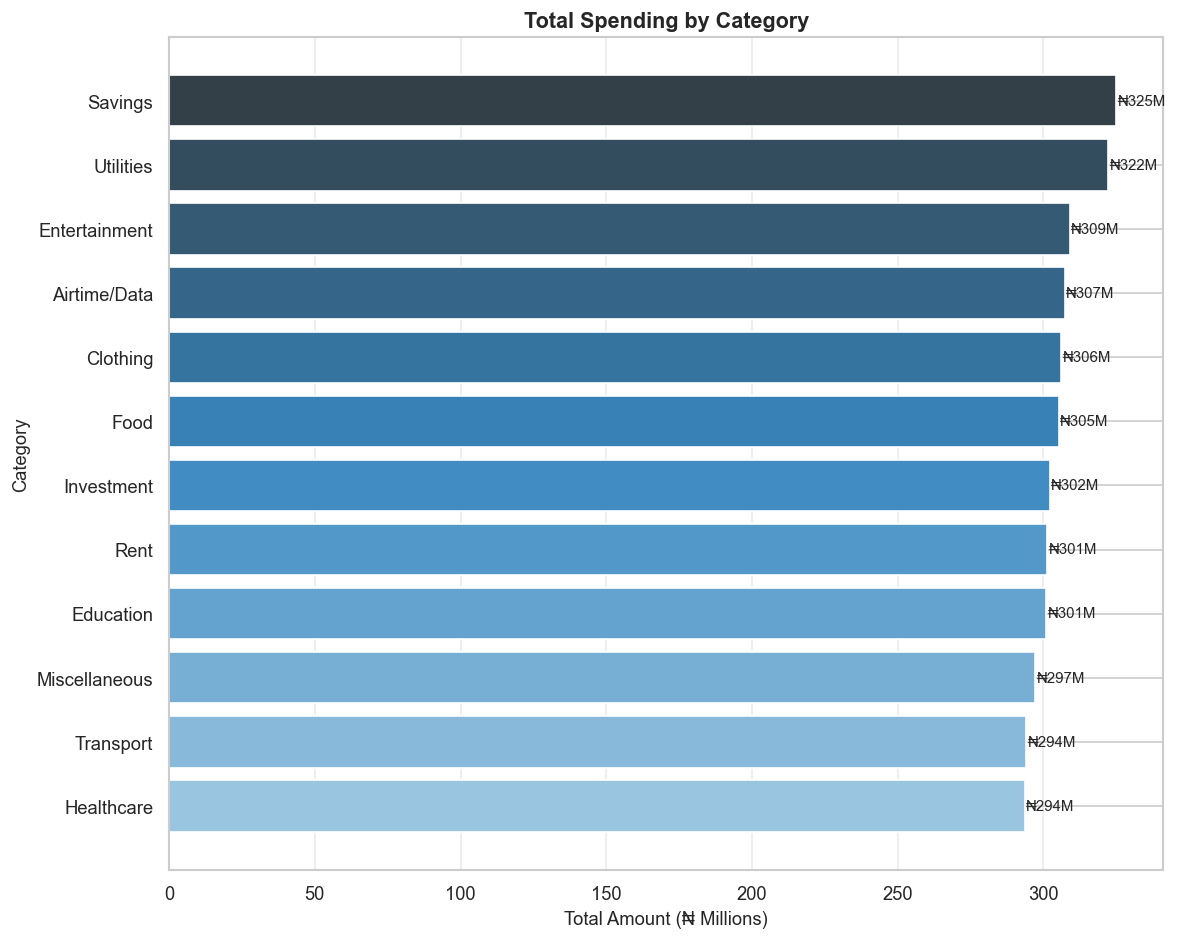

In [3]:
# ================================================
# Task 3 — Bar Chart: Total spending by category
# Shows which categories consume the most money
# ================================================

# Get total spending per category (expenses only)
category_spend = (expense_df.groupby('category')['amount_ngn']
                  .sum()
                  .reset_index()
                  .sort_values('amount_ngn', ascending=True))

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(category_spend['category'],
               category_spend['amount_ngn'] / 1e6,
               color=sns.color_palette('Blues_d', 
                                       len(category_spend)))

# Add value labels
for bar, val in zip(bars, category_spend['amount_ngn'] / 1e6):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'₦{val:.0f}M', va='center', fontsize=9)

ax.set_title('Total Spending by Category', fontweight='bold')
ax.set_xlabel('Total Amount (₦ Millions)')
ax.set_ylabel('Category')
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

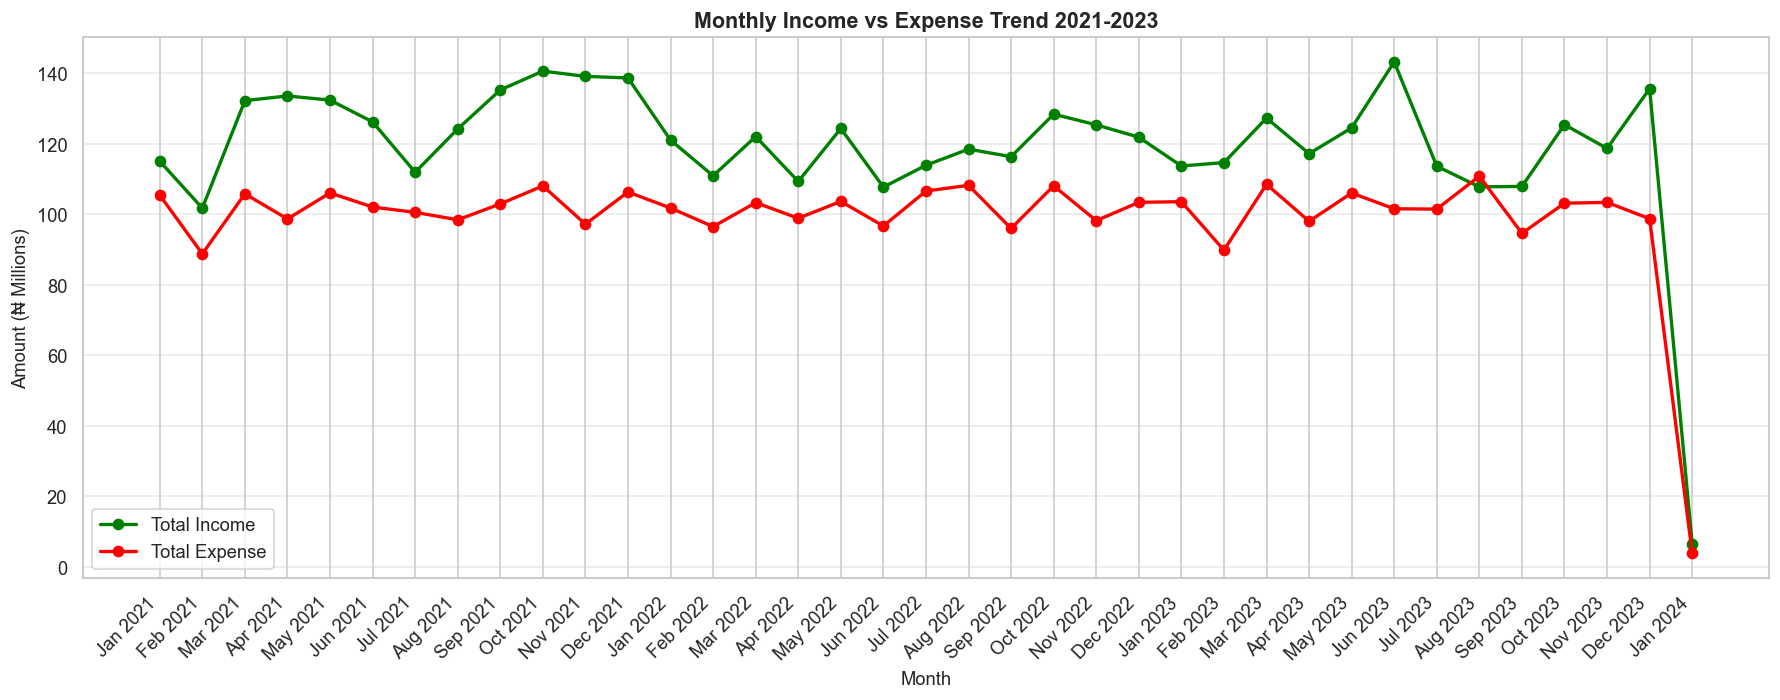

In [4]:
# ================================================
# Task 4 — Line Chart: Monthly income vs expense
# trend aggregated across all users
# ================================================

# Define correct month order
month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

# Aggregate income by month across all users
monthly_income_trend = (income_df.groupby(['year', 'month'])
                        ['amount_ngn'].sum()
                        .reset_index()
                        .rename(columns={'amount_ngn': 'total_income'}))

# Aggregate expense by month across all users
monthly_expense_trend = (expense_df.groupby(['year', 'month'])
                         ['amount_ngn'].sum()
                         .reset_index()
                         .rename(columns={'amount_ngn': 'total_expense'}))

# Merge both
monthly_trend = pd.merge(monthly_income_trend,
                         monthly_expense_trend,
                         on=['year', 'month'], how='outer').fillna(0)

# Sort by year and month order
monthly_trend['month_num'] = pd.Categorical(
    monthly_trend['month'],
    categories=month_order, ordered=True)
monthly_trend = monthly_trend.sort_values(
    ['year', 'month_num']).reset_index(drop=True)
monthly_trend['period'] = (monthly_trend['month'].str[:3] + 
                           ' ' + monthly_trend['year'].astype(str))

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(monthly_trend['period'],
        monthly_trend['total_income'] / 1e6,
        marker='o', linewidth=2,
        label='Total Income', color='green')

ax.plot(monthly_trend['period'],
        monthly_trend['total_expense'] / 1e6,
        marker='o', linewidth=2,
        label='Total Expense', color='red')

ax.set_title('Monthly Income vs Expense Trend 2021-2023',
             fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount (₦ Millions)')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [5]:
# ================================================
# Data Quality Fix — Check and remove 2024 data
# ================================================

print("Rows per year:")
print(df['year'].value_counts().sort_index())

Rows per year:
year
2021    25133
2022    24926
2023    24863
2024       78
Name: count, dtype: int64


In [6]:
# ================================================
# Data Quality Fix — Removing 78 invalid 2024 rows
# Note: 2024 had only 78 rows compared to ~25,000
# rows per valid year. Decision: Remove to maintain
# data integrity for 2021-2023 analysis period.
# ================================================

# Remove 2024 rows
df = df[df['year'] != 2024]

# Update income and expense dataframes too
income_df  = df[df['transaction_type'] == 'Income'].copy()
expense_df = df[df['transaction_type'] == 'Expense'].copy()

# Confirm clean
print("Remaining rows:", len(df))
print("Years now:", sorted(df['year'].unique()))
print("Income transactions:", len(income_df))
print("Expense transactions:", len(expense_df))

Remaining rows: 74922
Years now: [np.int64(2021), np.int64(2022), np.int64(2023)]
Income transactions: 11436
Expense transactions: 63486


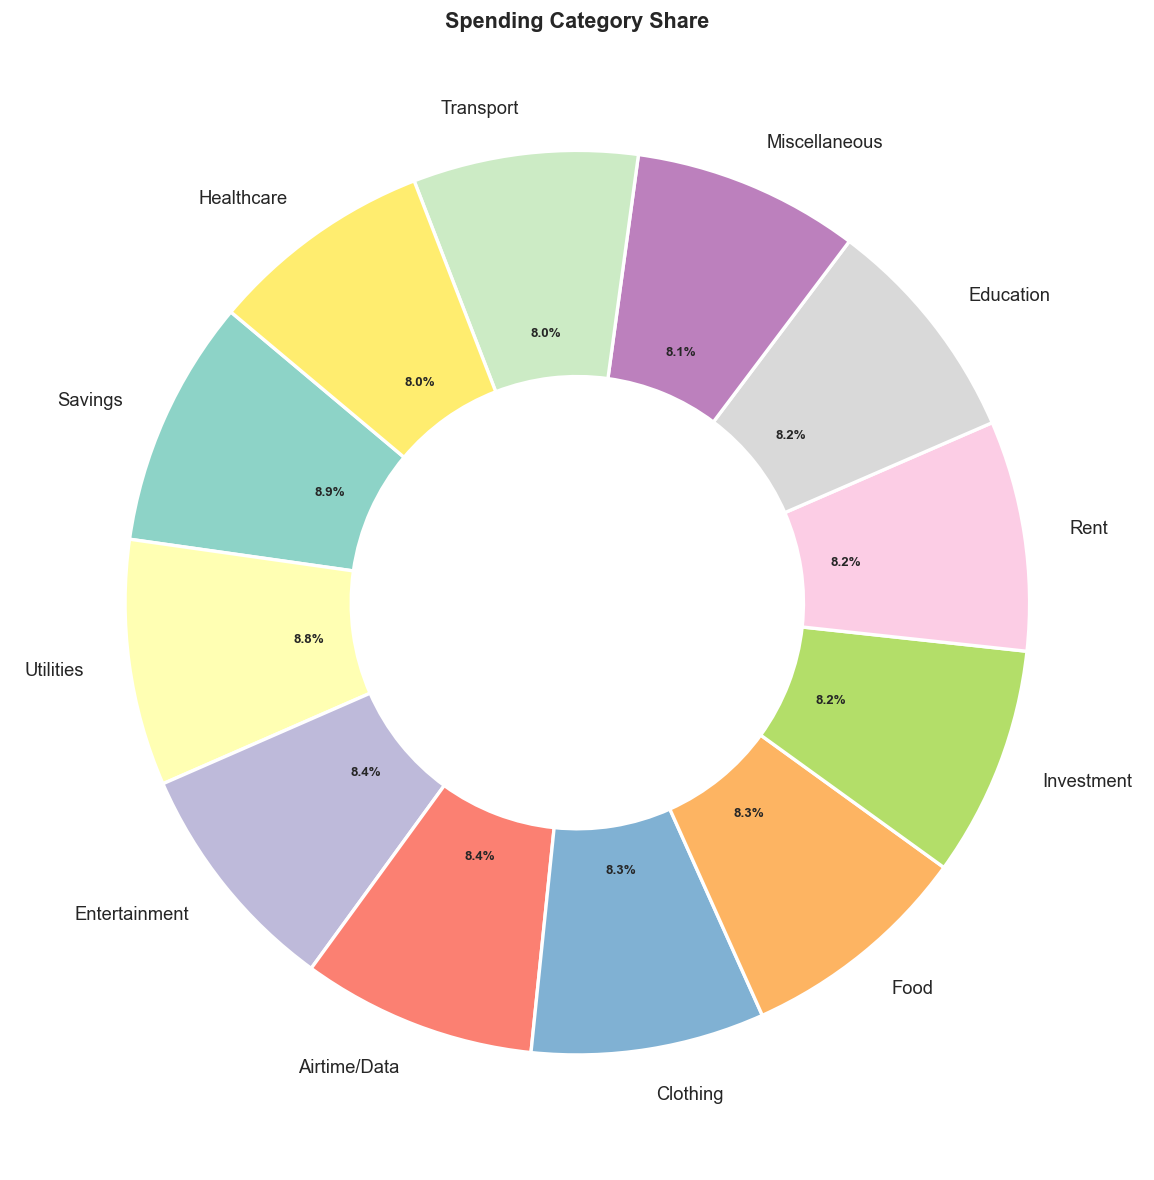

In [7]:
# ================================================
# Task 5 — Pie Chart: Spending category share
# Shows percentage contribution of each category
# to total spending
# ================================================

# Get spending share per category
category_share = (expense_df.groupby('category')['amount_ngn']
                  .sum()
                  .reset_index()
                  .sort_values('amount_ngn', ascending=False))

fig, ax = plt.subplots(figsize=(10, 10))

wedges, texts, autotexts = ax.pie(
    category_share['amount_ngn'],
    labels=category_share['category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set3', len(category_share)),
    wedgeprops=dict(width=0.5,
                    edgecolor='white',
                    linewidth=2)
)

# Make percentage text bigger
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

ax.set_title('Spending Category Share',
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

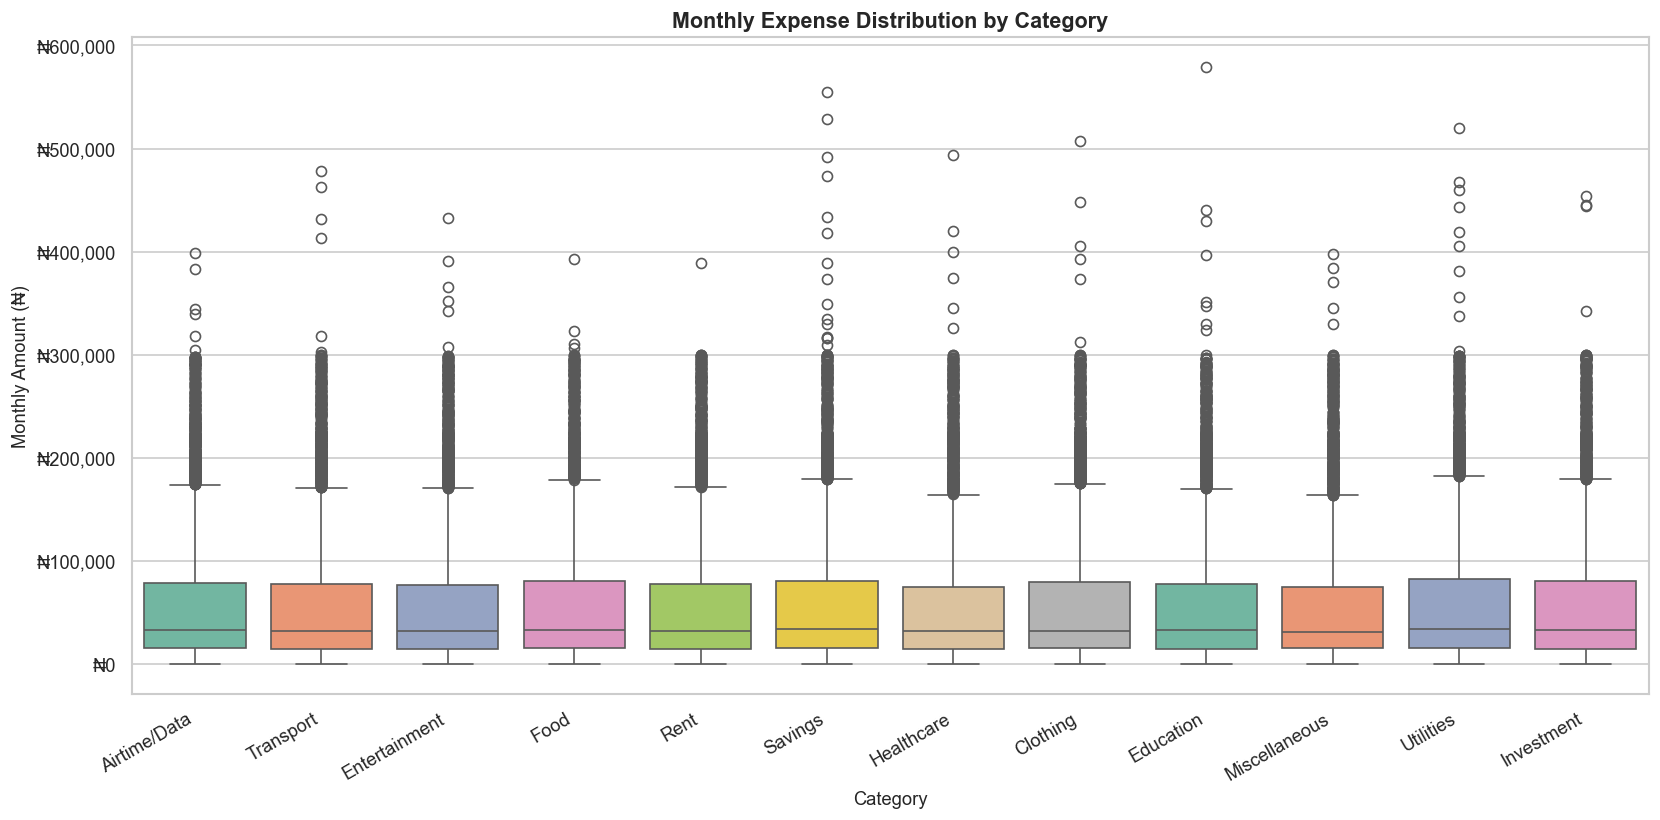

In [8]:
# ================================================
# Task 6 — Box Plot: Monthly expense distribution
# by category showing spread of spending
# ================================================

# Calculate monthly expense per user per category
monthly_cat = (expense_df.groupby(
                ['user_id', 'year', 'month', 'category'])
               ['amount_ngn'].sum()
               .reset_index())

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(data=monthly_cat,
            x='category',
            y='amount_ngn',
            palette='Set2',
            ax=ax)

ax.set_title('Monthly Expense Distribution by Category',
             fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Monthly Amount (₦)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₦{x:,.0f}'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

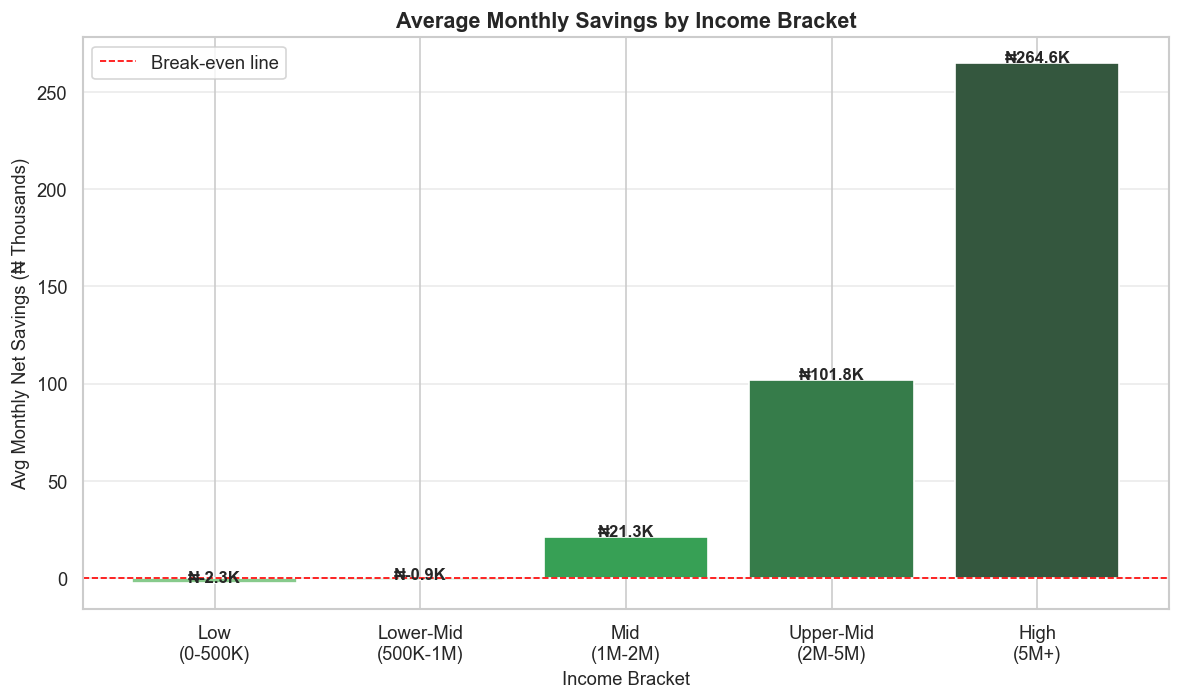

In [9]:
# ================================================
# Task 7 — Bar Chart: Average monthly savings
# by user income bracket
# ================================================

# Calculate total income per user
user_income = (income_df.groupby('user_id')['amount_ngn']
               .sum()
               .reset_index()
               .rename(columns={'amount_ngn': 'total_income'}))

# Create income brackets
user_income['income_bracket'] = pd.cut(
    user_income['total_income'],
    bins=[0, 500000, 1000000, 2000000, 5000000, float('inf')],
    labels=['Low\n(0-500K)', 'Lower-Mid\n(500K-1M)',
            'Mid\n(1M-2M)', 'Upper-Mid\n(2M-5M)',
            'High\n(5M+)'])

# Merge with monthly savings
monthly_savings_bracket = pd.merge(
    monthly_savings, user_income[['user_id', 'income_bracket']],
    on='user_id', how='left')

# Calculate average monthly savings per bracket
bracket_savings = (monthly_savings_bracket
                   .groupby('income_bracket')['net_savings']
                   .mean()
                   .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(bracket_savings['income_bracket'],
              bracket_savings['net_savings'] / 1e3,
              color=sns.color_palette('Greens_d', 5))

# Add value labels
for bar, val in zip(bars, bracket_savings['net_savings'] / 1e3):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'₦{val:.1f}K',
            ha='center', fontsize=10,
            fontweight='bold')

ax.set_title('Average Monthly Savings by Income Bracket',
             fontweight='bold')
ax.set_xlabel('Income Bracket')
ax.set_ylabel('Avg Monthly Net Savings (₦ Thousands)')
ax.axhline(y=0, color='red', linestyle='--',
           linewidth=1, label='Break-even line')
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

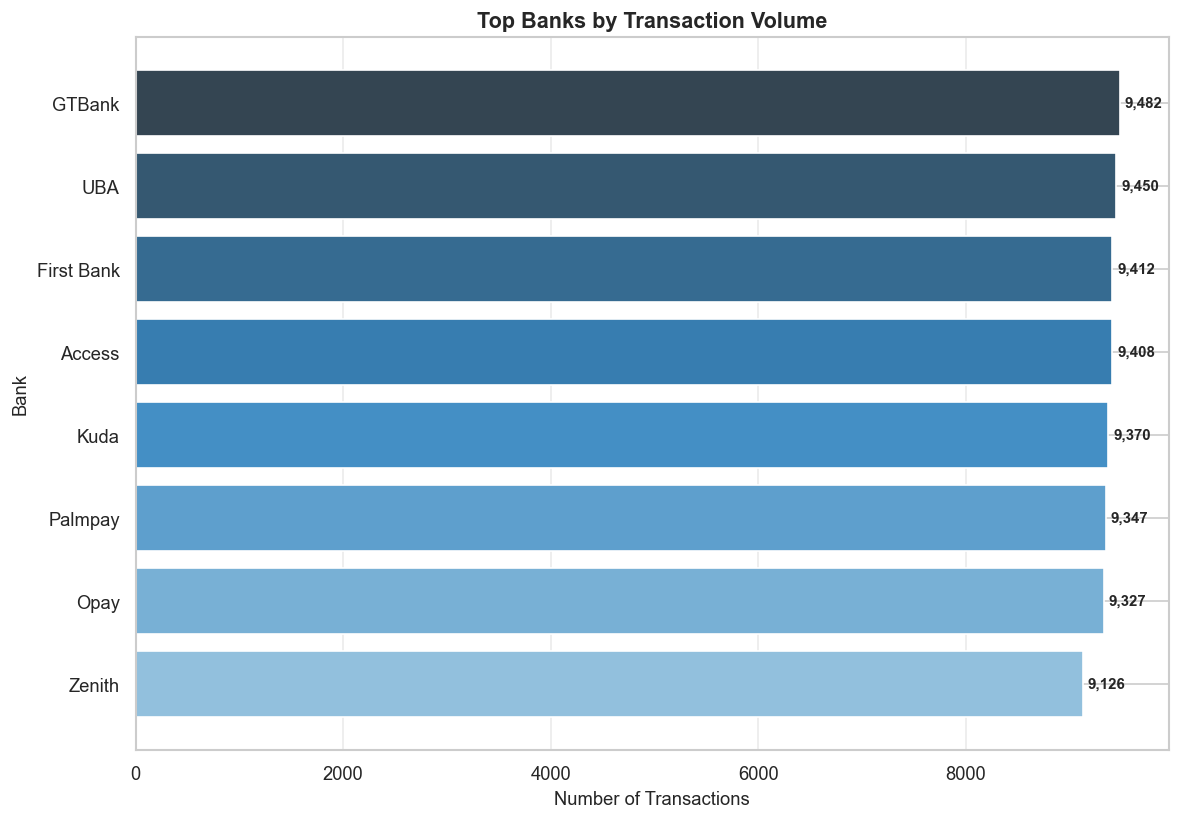

In [10]:
# ================================================
# Task 8 — Bar Chart: Top banks by transaction
# volume showing most used banking platforms
# ================================================

# Count transactions per bank
bank_volume = (df.groupby('bank')
               .agg(transaction_count=('transaction_id', 'count'),
                    total_amount=('amount_ngn', 'sum'))
               .reset_index()
               .sort_values('transaction_count', ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(bank_volume['bank'],
               bank_volume['transaction_count'],
               color=sns.color_palette('Blues_d',
                                       len(bank_volume)))

# Add value labels
for bar, val in zip(bars, bank_volume['transaction_count']):
    ax.text(val + 50,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9,
            fontweight='bold')

ax.set_title('Top Banks by Transaction Volume',
             fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Bank')
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

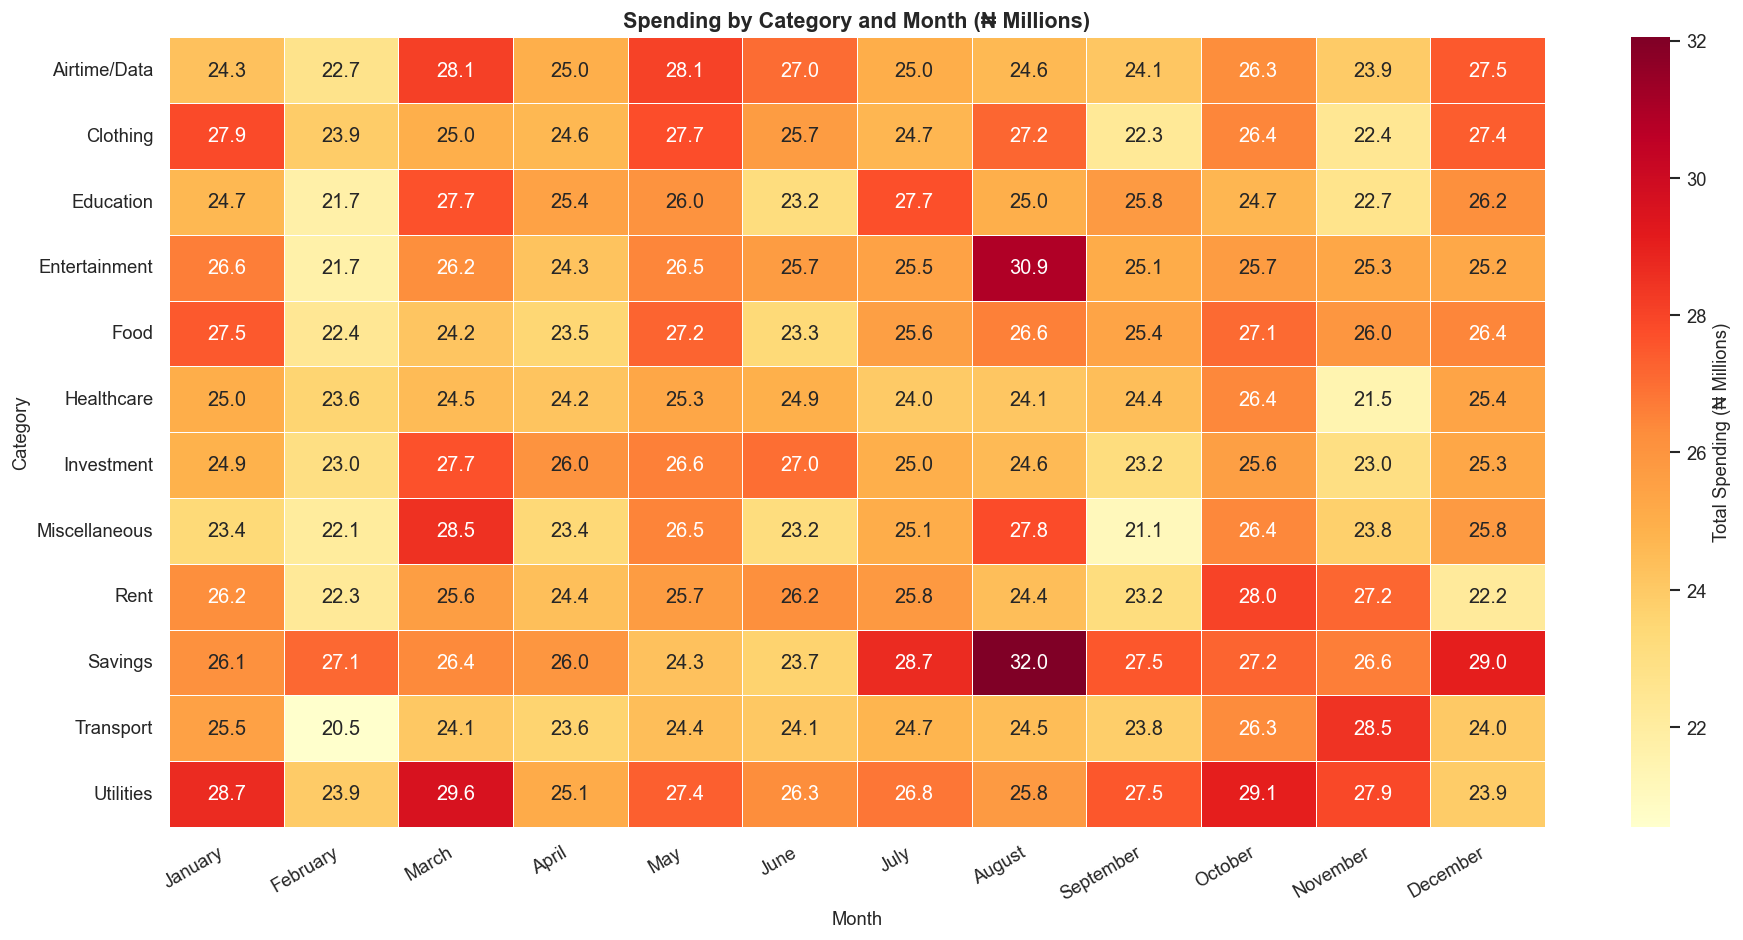

In [11]:
# ================================================
# Task 9 — Heatmap: Spending by category and month
# Shows seasonal spending patterns per category
# ================================================

# Define correct month order
month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

# Group spending by category and month
heatmap_data = (expense_df.groupby(['category', 'month'])
                ['amount_ngn'].sum()
                .reset_index()
                .pivot(index='category',
                       columns='month',
                       values='amount_ngn'))

# Reorder columns by correct month order
heatmap_data = heatmap_data.reindex(columns=month_order)

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(heatmap_data / 1e6,
            annot=True,
            fmt='.1f',
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Total Spending (₦ Millions)'})

ax.set_title('Spending by Category and Month (₦ Millions)',
             fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Category')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [12]:
# ================================================
# Task 10 — Flag over-spenders
# Users where expenses > income in more than 
# 3 months
# ================================================

# Calculate net savings per user per month
user_monthly = pd.merge(
    income_df.groupby(['user_id', 'year', 'month'])
    ['amount_ngn'].sum().reset_index()
    .rename(columns={'amount_ngn': 'total_income'}),
    expense_df.groupby(['user_id', 'year', 'month'])
    ['amount_ngn'].sum().reset_index()
    .rename(columns={'amount_ngn': 'total_expense'}),
    on=['user_id', 'year', 'month'],
    how='outer').fillna(0)

# Flag months where expense > income
user_monthly['overspent'] = (
    user_monthly['total_expense'] > 
    user_monthly['total_income']).astype(int)

# Count overspent months per user
overspend_count = (user_monthly.groupby('user_id')
                   ['overspent'].sum()
                   .reset_index()
                   .rename(columns={'overspent': 
                                    'overspent_months'}))

# Flag users who overspent more than 3 months
overspenders = overspend_count[
    overspend_count['overspent_months'] > 3]

print("=== Over-Spender Analysis ===")
print(f"Total users analysed:     {len(overspend_count):,}")
print(f"Over-spenders (>3 months): {len(overspenders):,}")
print(f"Percentage of users:       {len(overspenders)/len(overspend_count)*100:.1f}%")
print(f"\nMax months overspent: {overspend_count['overspent_months'].max()}")
print(f"Avg months overspent: {overspend_count['overspent_months'].mean():.1f}")

print("\nTop 10 worst over-spenders:")
print(overspend_count.nlargest(10, 'overspent_months'))

=== Over-Spender Analysis ===
Total users analysed:     5,000
Over-spenders (>3 months): 4,982
Percentage of users:       99.6%

Max months overspent: 21
Avg months overspent: 10.1

Top 10 worst over-spenders:
         user_id  overspent_months
2124  USR-502124                21
2295  USR-502295                21
1900  USR-501900                20
827   USR-500827                19
1963  USR-501963                19
2686  USR-502686                19
2870  USR-502870                19
240   USR-500240                18
408   USR-500408                18
441   USR-500441                18


## Task 10 Findings — Over-Spender Analysis

- 99.6% of users (4,982 out of 5,000) overspent
  in more than 3 months across 2021-2023
- Average user overspent in 10.1 out of 36 months
  meaning users struggle financially for almost 
  a third of the year on average
- Worst cases overspent in 21 out of 36 months
  indicating severe and chronic financial distress
- This finding strongly validates FinTrack's need
  for budget alerts, spending limits and 
  personalised financial recommendations
- Only 18 users (0.4%) maintained healthy spending
  in 3 or fewer months — these are model users
  whose behaviour should inform app recommendations

## Task 11 — 5 Product Insights for FinTrack

**Insight 1 — Overspending is Almost Universal**
99.6% of users overspend in more than 3 months per year.
FinTrack must make budget alerts and spending limits
core features not optional add-ons.

**Insight 2 — Low Income Users Need Most Help**
Users earning below ₦1M monthly have negative average
savings. FinTrack should offer simplified budget templates
and aggressive savings nudges for this segment.

**Insight 3 — August is Peak Financial Activity Month**
Both savings and entertainment spending peak in August.
FinTrack should send proactive budget reminders in
July to help users prepare for August spending surges.

**Insight 4 — GTBank Dominates User Banking**
GTBank leads in transaction volume across all 8 banks.
FinTrack should prioritise GTBank API integration for
seamless transaction syncing and real-time alerts.

**Insight 5 — Savings Category Leads Spending**
Users actively prioritise savings at 8.9% of total spend.
FinTrack should celebrate and reinforce this behaviour
with savings milestones, badges and goal tracking features.

In [13]:
# ================================================
# Save SQL import CSV with simplified data types
# ================================================

df_sql = df[['transaction_id', 'user_id', 
             'transaction_date', 'month', 'year',
             'transaction_type', 'category', 
             'amount_ngn', 'description',
             'payment_method', 'bank', 
             'savings_goal_met', 'budget_category',
             'notes']].copy()

# Convert date to string format MySQL accepts
df_sql['transaction_date'] = df_sql[
    'transaction_date'].dt.strftime('%Y-%m-%d')

# Save
df_sql.to_csv('fintrack_sql_import.csv', index=False)
print("Saved successfully!")
print("Rows:", len(df_sql))
print("Sample dates:", df_sql['transaction_date'].head(3).tolist())

Saved successfully!
Rows: 74922
Sample dates: ['2022-11-29', '2021-02-14', '2021-08-16']
